# Consumer Complaint EDA

Bank of America complaints received from January 2024 to February 2026. This is the prepared eight-category subset, with previously identified duplicate narratives and cross-company matches already removed.

Source: [CFPB narrative archive](https://www.consumerfinance.gov/foia-requests/foia-electronic-reading-room/cfpb-consumer-complaint-database-narratives-archive/).

## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textwrap import fill
from IPython.display import display

%matplotlib inline
pd.set_option("display.max_colwidth",120)
df=pd.read_csv("original_dataset.csv",dtype={"Complaint ID":"string","Narrative group ID":"string"})
text_col="Consumer complaint narrative"

## Basic Inspection

In [2]:
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
display(df.head(3))
df.info()

Shape: (16407, 7)
Columns: ['Complaint ID', 'Date received', 'Company', 'Consumer complaint narrative', 'Product', 'Narrative group ID', 'Source URL']


,Complaint ID,Date received,Company,Consumer complaint narrative,Product,Narrative group ID,Source URL
0,8085192,2024-01-01,"BANK OF AMERICA, NATIONAL ASSOCIATION","In XXXXXXXX XXXX XXXX I made a payment to BOA, where I had 2 credit cards. I made the payment to the wrong card, bu...",Credit card,1dad0e9edbc652044c356c64771caa4286e2da706b5a8c35b555d26951a4631d,https://files.consumerfinance.gov/f/documents/CCDB_Export_5_September_2023_through_March_2024.zip
1,8085213,2024-01-01,"BANK OF AMERICA, NATIONAL ASSOCIATION",THIS COMPLAINT IS TO SHOW THE CONSUMER FINANCIAL PROTECTION BUREAU OF MY NOTICE TO BANK OF AMERICA OF THEIR UNLAWFUL...,Credit reporting or other personal consumer reports,2c359e360ed8e1d53f79b1d23f673e9f7c5f075a9dae69ac90a5d6a78ac94f1d,https://files.consumerfinance.gov/f/documents/CCDB_Export_5_September_2023_through_March_2024.zip
2,8085301,2024-01-01,"BANK OF AMERICA, NATIONAL ASSOCIATION",I made an insurance payment of {$130.00} for my auto insurance. Everything appeared okay with this until I received ...,Checking or savings account,2037a094c84cbdeaf6ebcd9277692bf763f773252a1a90660c430f46bcec502e,https://files.consumerfinance.gov/f/documents/CCDB_Export_5_September_2023_through_March_2024.zip


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16407 entries, 0 to 16406
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Complaint ID                  16407 non-null  string
 1   Date received                 16407 non-null  object
 2   Company                       16407 non-null  object
 3   Consumer complaint narrative  16407 non-null  object
 4   Product                       16407 non-null  object
 5   Narrative group ID            16407 non-null  string
 6   Source URL                    16407 non-null  object
dtypes: object(5), string(2)
memory usage: 897.4+ KB


In [3]:
display(df.nunique().rename("unique_values").to_frame())
display(df[["Product","Company"]].describe().T)

,unique_values
Complaint ID,16407
Date received,758
Company,1
Consumer complaint narrative,16407
Product,8
Narrative group ID,16407
Source URL,11


,count,unique,top,freq
Product,16407,8,Checking or savings account,6740
Company,16407,1,"BANK OF AMERICA, NATIONAL ASSOCIATION",16407


The narrative contains the complaint text and Product contains its category. IDs, dates, narrative group IDs and source links are retained for reference. Company has one value. Issue, sub-product and state columns are not present in this file.

## Data Quality

In [4]:
quality=pd.DataFrame({
    "missing":df.isna().sum(),
    "empty_or_whitespace":df.apply(lambda col:col.astype("string").str.strip().eq("").sum())
})
display(quality)

text=df[text_col].astype("string")
missing_markers=["na","n/a","null","none","nan","not provided"]
print("Narratives containing only a missing-value marker:",text.str.strip().str.casefold().isin(missing_markers).sum())

,missing,empty_or_whitespace
Complaint ID,0,0
Date received,0,0
Company,0,0
Consumer complaint narrative,0,0
Product,0,0
Narrative group ID,0,0
Source URL,0,0


Narratives containing only a missing-value marker: 0


In [5]:
normalized=text.str.replace(r"\s+"," ",regex=True).str.strip()
duplicate_counts=pd.Series({
    "exact_rows":df.duplicated().sum(),
    "complaint_ids":df["Complaint ID"].duplicated().sum(),
    "exact_narratives":text.duplicated().sum(),
    "narratives_ignoring_case_and_whitespace":normalized.str.casefold().duplicated().sum(),
    "narrative_group_ids":df["Narrative group ID"].duplicated().sum()
},name="duplicates")
display(duplicate_counts.to_frame())
print("Narratives changed by whitespace normalization:",text.ne(normalized).sum())

,duplicates
exact_rows,0
complaint_ids,0
exact_narratives,0
narratives_ignoring_case_and_whitespace,0
narrative_group_ids,0


Narratives changed by whitespace normalization: 10190


In [6]:
dates=pd.to_datetime(df["Date received"],format="%Y-%m-%d",errors="coerce")
label_variants=df.groupby(df["Product"].str.strip().str.casefold())["Product"].nunique()
checks=pd.Series({
    "invalid_dates":dates.isna().sum(),
    "product_labels_with_case_or_whitespace_variants":label_variants.gt(1).sum(),
    "product_labels_with_edge_whitespace":df["Product"].ne(df["Product"].str.strip()).sum(),
    "non_numeric_complaint_ids":(~df["Complaint ID"].str.fullmatch(r"\d+")).sum(),
    "invalid_narrative_group_ids":(~df["Narrative group ID"].str.fullmatch(r"[0-9a-f]{64}")).sum(),
    "non_CFPB_source_links":(~df["Source URL"].str.startswith("https://files.consumerfinance.gov/")).sum()
},name="count")
display(checks.to_frame())
print("Date range:",dates.min().date(),"to",dates.max().date())

,count
invalid_dates,0
product_labels_with_case_or_whitespace_variants,0
product_labels_with_edge_whitespace,0
non_numeric_complaint_ids,0
invalid_narrative_group_ids,0
non_CFPB_source_links,0


Date range: 2024-01-01 to 2026-02-02


## Complaint Text Inspection

In [7]:
original_lengths=pd.DataFrame({
    "characters":text.str.len(),
    "words":text.str.split().str.len()
})
display(original_lengths.describe(percentiles=[.5,.9,.95,.99]).round(1))
print("Complaints with fewer than 10 words:",original_lengths["words"].lt(10).sum())
print("Complaints with redaction markers:",text.str.contains(r"\bX{2,}\b",regex=True).sum())
print("Complaints with literal \\n sequences:",text.str.contains(r"\n",regex=False).sum())

,characters,words
count,16407.0,16407.0
mean,1355.5,238.1
std,1443.9,250.1
min,14.0,2.0
50%,996.0,177.0
90%,2739.4,475.0
95%,3644.0,627.0
99%,6832.6,1188.7
max,31557.0,5699.0


Complaints with fewer than 10 words: 52
Complaints with redaction markers: 14506


Complaints with literal \n sequences: 81


In [8]:
examples=df[["Complaint ID","Product"]].join(original_lengths)
examples["preview"]=text.str.slice(0,300)
print("Shortest complaints")
display(examples.nsmallest(5,"words"))
print("Longest complaints (first 300 characters)")
display(examples.nlargest(3,"words"))

markup=text.str.extract(r"(</?[A-Za-z][^>]*>)",expand=False)
display(df.loc[markup.notna(),["Complaint ID"]].assign(matched_text=markup[markup.notna()]))

Shortest complaints


,Complaint ID,Product,characters,words,preview
2122,8814838,Credit reporting or other personal consumer reports,20,2,Unauthorized Inquiry
3156,9267702,Credit reporting or other personal consumer reports,20,2,Unrecognized account
3162,9271378,Credit reporting or other personal consumer reports,14,3,Not my account
1896,8730351,Debt collection,22,4,Dispute auto loan debt
510,8238425,Checking or savings account,25,5,Account unable to be open


Longest complaints (first 300 characters)


,Complaint ID,Product,characters,words,preview
11320,14369012,"Money transfer, virtual currency, or money service",31271,5699,b'Summary of XXXXTestimony\nXXXX Testimony \n\nXXXX XXXX XXXX XXXX contacted me and offered me to work full/part ti...
3779,9561046,"Money transfer, virtual currency, or money service",31557,4989,"I wish to practice my right as a customer of Bank of America to use your organisation's service, seeking a formal, i..."
1141,8461336,Checking or savings account,24016,4449,On XXXX XXXX and while sitting and listening to the computer keyboard get repeatedly clicked by XXXX while she (tw...


,Complaint ID,matched_text
11602,14559080,<which B of A engineered>


Short complaints include meaningful phrases such as "Unrecognized account" and "Unauthorized Inquiry", so length alone is not a reason to remove them. Long complaints and literal escape sequences are retained as published. The angle-bracket match is a phrase within a complaint, not an HTML tag.

## Data Cleaning

No rows need removal based on the missing-value and duplicate checks. Normalize whitespace only. Keep the original wording, capitalization, punctuation, numbers and redaction markers.

In [9]:
cleaned=df.copy()
cleaned[text_col]=cleaned[text_col].str.replace(r"\s+"," ",regex=True).str.strip()
changed=df[text_col].ne(cleaned[text_col])
print("Narratives with whitespace changes:",changed.sum())
print("Rows removed:",len(df)-len(cleaned))

Narratives with whitespace changes: 10190
Rows removed: 0


## Complaint Lengths

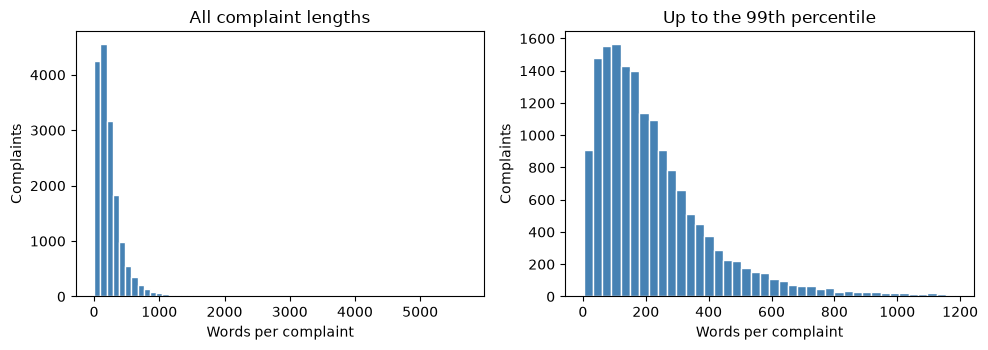

Long complaints outside the zoomed plot, retained in the data: 165


In [10]:
lengths=pd.DataFrame({
    "characters":cleaned[text_col].str.len(),
    "words":cleaned[text_col].str.split().str.len()
})
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].hist(lengths["words"],bins=60,color="steelblue",edgecolor="white")
axes[0].set_title("All complaint lengths")
axes[0].set_xlabel("Words per complaint")
axes[0].set_ylabel("Complaints")

limit=lengths["words"].quantile(.99)
axes[1].hist(lengths.loc[lengths["words"].le(limit),"words"],bins=40,color="steelblue",edgecolor="white")
axes[1].set_title("Up to the 99th percentile")
axes[1].set_xlabel("Words per complaint")
axes[1].set_ylabel("Complaints")
plt.tight_layout()
plt.show()
print("Long complaints outside the zoomed plot, retained in the data:",lengths["words"].gt(limit).sum())

## Product Categories

,complaints,percent
Product,,
Checking or savings account,6740,41.08
Credit card,4119,25.11
Credit reporting or other personal consumer reports,2119,12.92
"Money transfer, virtual currency, or money service",1542,9.40
Debt collection,609,3.71
Prepaid card,543,3.31
Mortgage,504,3.07
Vehicle loan or lease,231,1.41


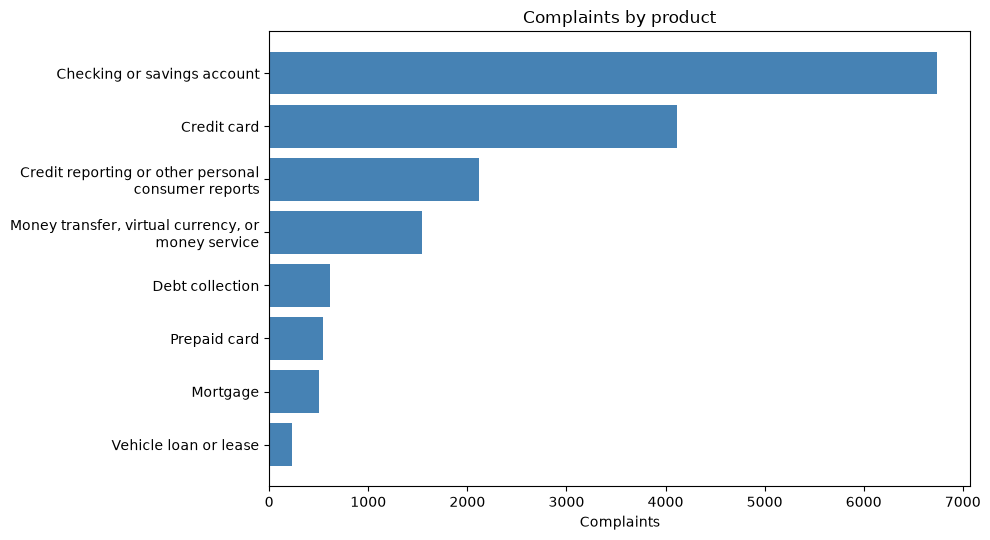

In [11]:
counts=cleaned["Product"].value_counts()
products=pd.DataFrame({
    "complaints":counts,
    "percent":counts.div(len(cleaned)).mul(100).round(2)
})
display(products)

ordered=counts.sort_values()
fig,ax=plt.subplots(figsize=(10,5.5))
ax.barh(np.arange(len(ordered)),ordered.values,color="steelblue")
ax.set_yticks(np.arange(len(ordered)))
ax.set_yticklabels([fill(label,36) for label in ordered.index])
ax.set_title("Complaints by product")
ax.set_xlabel("Complaints")
plt.tight_layout()
plt.show()

The categories are uneven: checking or savings accounts account for about 41% of complaints, while vehicle loans or leases account for about 1.4%. These counts describe this selected dataset, not the bank's overall customers.

## Final Dataset

In [12]:
final_checks=pd.Series({
    "rows":len(cleaned),
    "columns":cleaned.shape[1],
    "usable_narratives":cleaned[text_col].fillna("").str.strip().ne("").sum(),
    "missing_narratives":cleaned[text_col].isna().sum(),
    "empty_narratives":cleaned[text_col].fillna("").str.strip().eq("").sum(),
    "missing_products":cleaned["Product"].isna().sum(),
    "empty_products":cleaned["Product"].fillna("").str.strip().eq("").sum(),
    "duplicate_rows":cleaned.duplicated().sum(),
    "duplicate_complaint_ids":cleaned["Complaint ID"].duplicated().sum(),
    "duplicate_normalized_narratives":cleaned[text_col].str.casefold().duplicated().sum(),
    "product_categories":cleaned["Product"].nunique()
},name="value")
display(final_checks.to_frame())
display(cleaned.isna().sum().rename("remaining_missing").to_frame())
display(lengths.describe(percentiles=[.5,.95,.99]).round(1))

assert cleaned.shape==df.shape
assert cleaned.drop(columns=text_col).equals(df.drop(columns=text_col))
assert cleaned[text_col].str.casefold().eq(normalized.str.casefold()).all()
assert cleaned["Product"].value_counts().equals(df["Product"].value_counts())
assert final_checks[["missing_narratives","empty_narratives","missing_products","empty_products","duplicate_rows","duplicate_complaint_ids","duplicate_normalized_narratives"]].eq(0).all()

,value
rows,16407
columns,7
usable_narratives,16407
missing_narratives,0
empty_narratives,0
missing_products,0
empty_products,0
duplicate_rows,0
duplicate_complaint_ids,0
duplicate_normalized_narratives,0


,remaining_missing
Complaint ID,0
Date received,0
Company,0
Consumer complaint narrative,0
Product,0
Narrative group ID,0
Source URL,0


,characters,words
count,16407.0,16407.0
mean,1350.8,238.1
std,1438.7,250.1
min,14.0,2.0
50%,993.0,177.0
95%,3628.1,627.0
99%,6811.0,1188.7
max,31535.0,5699.0


In [13]:
cleaned.to_csv("cleaned_consumer_complaints.csv",index=False,encoding="utf-8-sig")
pd.DataFrame({
    "original_rows":[len(df)],
    "cleaned_rows":[len(cleaned)],
    "rows_removed":[len(df)-len(cleaned)],
    "narratives_with_whitespace_changes":[int(changed.sum())]
})

,original_rows,cleaned_rows,rows_removed,narratives_with_whitespace_changes
0,16407,16407,0,10190
